In [17]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sys.path.append('..')

from utils.label_creation import AutoTaggerServiceNow

# Initialize
tagger = AutoTaggerServiceNow(use_async=False, max_workers=5)

In [18]:
# Test connection
tagger.test_connection()

INFO:httpx:HTTP Request: POST https://ai-coe-openai-models-latest.openai.azure.com/openai/deployments/gpt-5/chat/completions?api-version=2025-01-01-preview "HTTP/1.1 200 OK"
INFO:utils.label_creation:✓ Connection successful!


True

## Run Predictions

Now we'll run the predictions and generate a structured CSV with:
- **number**: Ticket ID
- **text**: Concatenated text (title + description + assignment_group)
- **label**: Classification label (e.g., "(1d Broadband, 2d Fiber), 3 product status")
- **reasoning**: Explanation for the classification
- **confidence_score**: Confidence score (0-1)

Each ticket will have **3 rows** in the output (one for each of the top 3 predictions).

In [19]:
df = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/combined_data_masked.csv')

In [20]:
# concat title, description and assignment_group into one column for prediction
df['text'] = df['title'] + ' ' + df['description'] + ' ' + df['assignment_group']
prediction_df = df[["number", "text"]].copy()

In [21]:
prediction_df.head()

,number,text
0,INC0133168,Support - YouSee mail/Issue with Mit YouSee/Ca...
1,INC0133171,Support - TV/Video on demand/Streamer or Audio...
2,INC0133177,Support - TV/Other/Bland Selv After the Custom...
3,INC0133167,Support - Dawn/With Customer context/Other It ...
4,INC0133169,Support - Dawn/With Customer context/Customer ...


In [22]:
# Create a small sample to test
df_test = prediction_df.sample(n=50,random_state=42)

In [23]:
# Run predictions and create CSV with structured output
# This will create a CSV with: number, text, label, reasoning, confidence_score
# Each ticket (number) will have 3 rows (top 3 predictions)

result_df = tagger.predict_and_create_csv(
    df=df_test,
    output_path='../data/prediction_results2.csv',
    number_column='number',
    text_column='text'
)

print(f"\nTotal predictions: {len(result_df)}")
print(f"Unique tickets: {result_df['number'].nunique()}")
result_df.head(9)  # Show first 3 tickets (9 rows)

INFO:utils.label_creation:Using parallel processing...
Processing tickets:   2%|██████████████████▊                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     


Total predictions: 150
Unique tickets: 50


,number,text,label,reasoning,confidence_score
0,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c COAX), 3 technical issues",ing: The symptom is incorrect/missing channel ...,0.60
1,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c Fiber), 3 technical issues",ing: Similar EPG/channel mapping issues can oc...,0.45
2,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c OTT), 3 technical issues",ing: If the customer is using YouSee’s OTT/Pla...,0.35
3,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 CPR issues in D...","(1 Misc incidents, 2 Other), 3 CPR issues in D...",0.95
4,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 Change ownershi...","(1 Misc incidents, 2 Other), 3 Change ownershi...",0.40
5,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 Billing/Invoice...","(1 Misc incidents, 2 Other), 3 Billing/Invoice...",0.35
6,INC0140020,Support - Dawn/With Customer context/Quotes an...,"(1d Broadband, 2d Fiber), 3 Missing rights to ...",ing: Dawn indicates it’s “locked” and won’t al...,0.70
7,INC0140020,Support - Dawn/With Customer context/Quotes an...,"(1d Broadband, 2d Fiber), 3 onsite technician",ing: The core issue is rescheduling a technici...,0.60
8,INC0140020,Support - Dawn/With Customer context/Quotes an...,"(1d Broadband, 2d COAX), 3 Missing rights to a...","ing: If the product is COAX, Dawn rebooking/pe...",0.40


## Compare Prediction Results - Randomness Analysis

Compare the two CSV files to check for randomness and consistency between runs.

In [24]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load both prediction results
df1 = pd.read_csv('../data/prediction_results.csv')
df2 = pd.read_csv('../data/prediction_results2.csv')

In [25]:
df1.head()

,number,text,label,reasoning,confidence_score
0,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 CPR issues in Dawn",ing: The issue concerns incorrect customer dat...,0.92
1,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1g Self service, 2g Mit YouSee), 3 CPR issues...",ing: If the incorrect name is reflected in the...,0.55
2,INC0143840,Support - Issues with Customer Data/CPR data i...,"(1 Misc incidents, 2 Other), 3 Change ownership",ing: Name/CPR corrections are sometimes handle...,0.38
3,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c OTT), 3 technical issues",ing: Viaplay Sport News is an OTT-integrated c...,0.62
4,INC0149456,Support - TV/Other/Other Viaplay sport news ca...,"(1c TV, 2c Fiber), 3 technical issues",ing: If the TV service is delivered via fiber/...,0.48


In [11]:
# Merge datasets for comparison (assuming same tickets and top-3 structure)
if len(df1) == len(df2):
    # Compare predictions
    label_match = (df1['label'] == df2['label']).sum()
    label_diff = len(df1) - label_match
    
    print("\n--- LABEL COMPARISON ---")
    print(f"Matching predictions: {label_match} ({label_match/len(df1)*100:.2f}%)")
    print(f"Different predictions: {label_diff} ({label_diff/len(df1)*100:.2f}%)")
    
    # Compare confidence scores
    conf_diff = np.abs(df1['confidence_score'] - df2['confidence_score'])
    
    print("\n--- CONFIDENCE SCORE COMPARISON ---")
    print(f"Mean absolute difference: {conf_diff.mean():.4f}")
    print(f"Max difference: {conf_diff.max():.4f}")
    print(f"Min difference: {conf_diff.min():.4f}")
    print(f"Std deviation of difference: {conf_diff.std():.4f}")
    
    # Group by ticket to see per-ticket consistency
    df1_sorted = df1.sort_values(['number', 'confidence_score'], ascending=[True, False]).reset_index(drop=True)
    df2_sorted = df2.sort_values(['number', 'confidence_score'], ascending=[True, False]).reset_index(drop=True)
    
    # Check if top prediction matches for each ticket
    top1_df1 = df1_sorted.groupby('number').first().reset_index()
    top1_df2 = df2_sorted.groupby('number').first().reset_index()
    
    top1_match = (top1_df1['label'] == top1_df2['label']).sum()
    unique_tickets = df1['number'].nunique()
    
    print("\n--- TOP-1 PREDICTION CONSISTENCY ---")
    print(f"Tickets with same top prediction: {top1_match}/{unique_tickets} ({top1_match/unique_tickets*100:.2f}%)")
else:
    print("\n⚠️ Warning: Datasets have different lengths!")


--- LABEL COMPARISON ---
Matching predictions: 32 (21.33%)
Different predictions: 118 (78.67%)

--- CONFIDENCE SCORE COMPARISON ---
Mean absolute difference: 0.1229
Max difference: 0.8400
Min difference: 0.0000
Std deviation of difference: 0.1501

--- TOP-1 PREDICTION CONSISTENCY ---
Tickets with same top prediction: 33/50 (66.00%)


In [12]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'number': df1['number'],
    'label_run1': df1['label'],
    'label_run2': df2['label'],
    'match': df1['label'] == df2['label'],
    'conf_run1': df1['confidence_score'],
    'conf_run2': df2['confidence_score'],
    'conf_diff': np.abs(df1['confidence_score'] - df2['confidence_score'])
})

print("\n--- SAMPLES OF DIFFERENT PREDICTIONS ---")
different_predictions = comparison_df[~comparison_df['match']]
print(f"\nTotal different predictions: {len(different_predictions)}")
if len(different_predictions) > 0:
    print("\nFirst 10 cases where predictions differ:")
    print(different_predictions.head(10))


--- SAMPLES OF DIFFERENT PREDICTIONS ---

Total different predictions: 118

First 10 cases where predictions differ:
       number                                         label_run1  \
0  INC0143840  (1 Misc incidents, 2 Other), 3 CPR issues in Dawn   
1  INC0143840  (1g Self service, 2g Mit YouSee), 3 CPR issues...   
2  INC0143840    (1 Misc incidents, 2 Other), 3 Change ownership   
3  INC0149456                (1c TV, 2c OTT), 3 technical issues   
4  INC0149456              (1c TV, 2c Fiber), 3 technical issues   
5  INC0149456                 (1c TV, 2c COAX), 3 product status   
6  INC0140020      (1d Broadband, 2d Fiber), 3 onsite technician   
7  INC0140020       (1d Broadband, 2d Fiber), 3 Order activation   
8  INC0140020  (1d Broadband, 2d Fiber), 3 Missing rights to ...   
9  INC0146057               (1g Self service, 2g YS-play), 3 App   

                                          label_run2  match  conf_run1  \
0                         (1c TV, 2c COAX), 3 Mix-tv  False

## EDA: Label Distribution Analysis

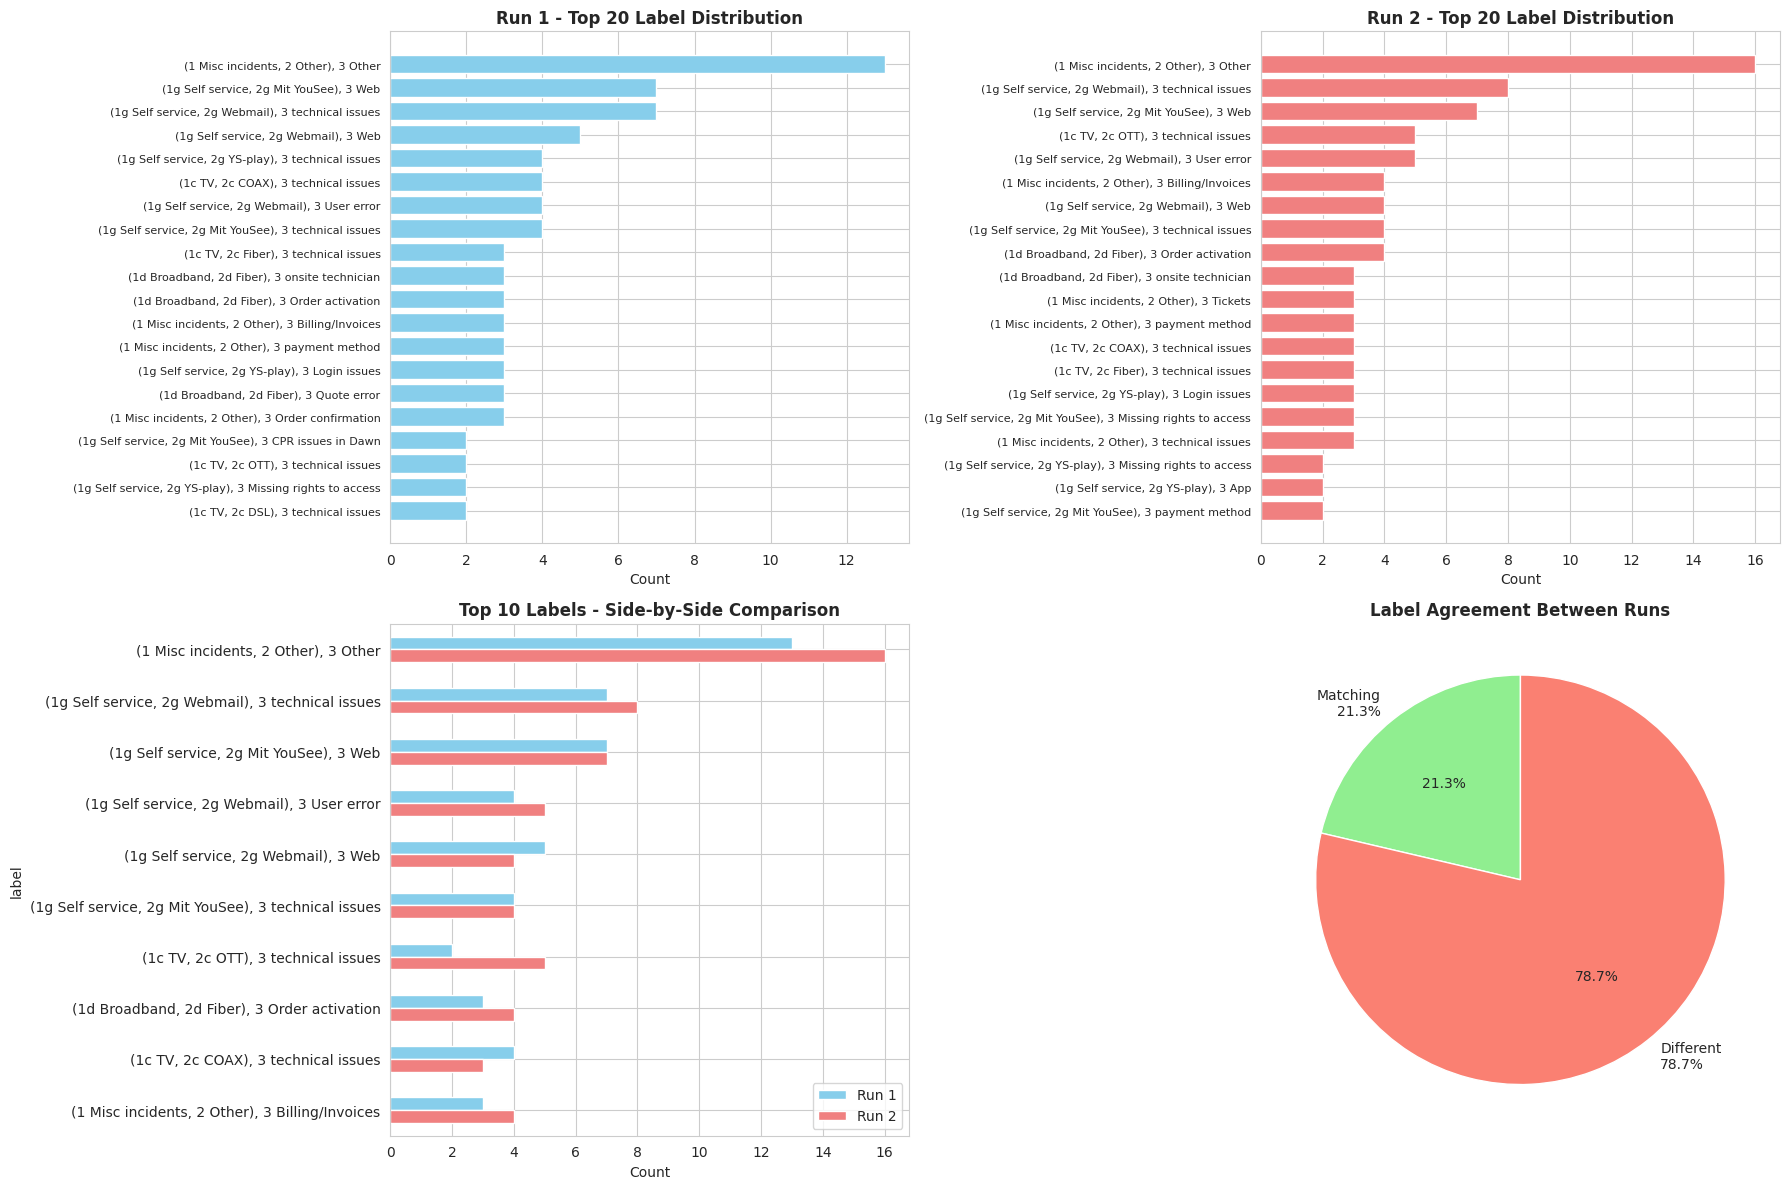


Unique labels in Run 1: 83
Unique labels in Run 2: 77


In [15]:
# Label distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Run 1 - Label distribution
label_counts_1 = df1['label'].value_counts().head(20)
axes[0, 0].barh(range(len(label_counts_1)), label_counts_1.values, color='skyblue')
axes[0, 0].set_yticks(range(len(label_counts_1)))
axes[0, 0].set_yticklabels(label_counts_1.index, fontsize=8)
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Run 1 - Top 20 Label Distribution', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()

# Run 2 - Label distribution
label_counts_2 = df2['label'].value_counts().head(20)
axes[0, 1].barh(range(len(label_counts_2)), label_counts_2.values, color='lightcoral')
axes[0, 1].set_yticks(range(len(label_counts_2)))
axes[0, 1].set_yticklabels(label_counts_2.index, fontsize=8)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Run 2 - Top 20 Label Distribution', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()

# Side-by-side comparison of top 10 labels
all_labels = pd.concat([df1['label'], df2['label']]).value_counts().head(10).index
comparison_data = pd.DataFrame({
    'Run 1': [df1[df1['label'] == label].shape[0] for label in all_labels],
    'Run 2': [df2[df2['label'] == label].shape[0] for label in all_labels]
}, index=all_labels)

comparison_data.plot(kind='barh', ax=axes[1, 0], color=['skyblue', 'lightcoral'])
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_title('Top 10 Labels - Side-by-Side Comparison', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='best')
axes[1, 0].invert_yaxis()

# Label match rate visualization
axes[1, 1].pie([label_match, label_diff], 
               labels=[f'Matching\n{label_match/len(df1)*100:.1f}%', 
                      f'Different\n{label_diff/len(df1)*100:.1f}%'],
               colors=['lightgreen', 'salmon'],
               autopct='%1.1f%%',
               startangle=90)
axes[1, 1].set_title('Label Agreement Between Runs', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nUnique labels in Run 1: {df1['label'].nunique()}")
print(f"Unique labels in Run 2: {df2['label'].nunique()}")

## EDA: Confidence Score Analysis

/tmp/ipykernel_24121/880074788.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(box_data, labels=['Run 1', 'Run 2'], patch_artist=True,


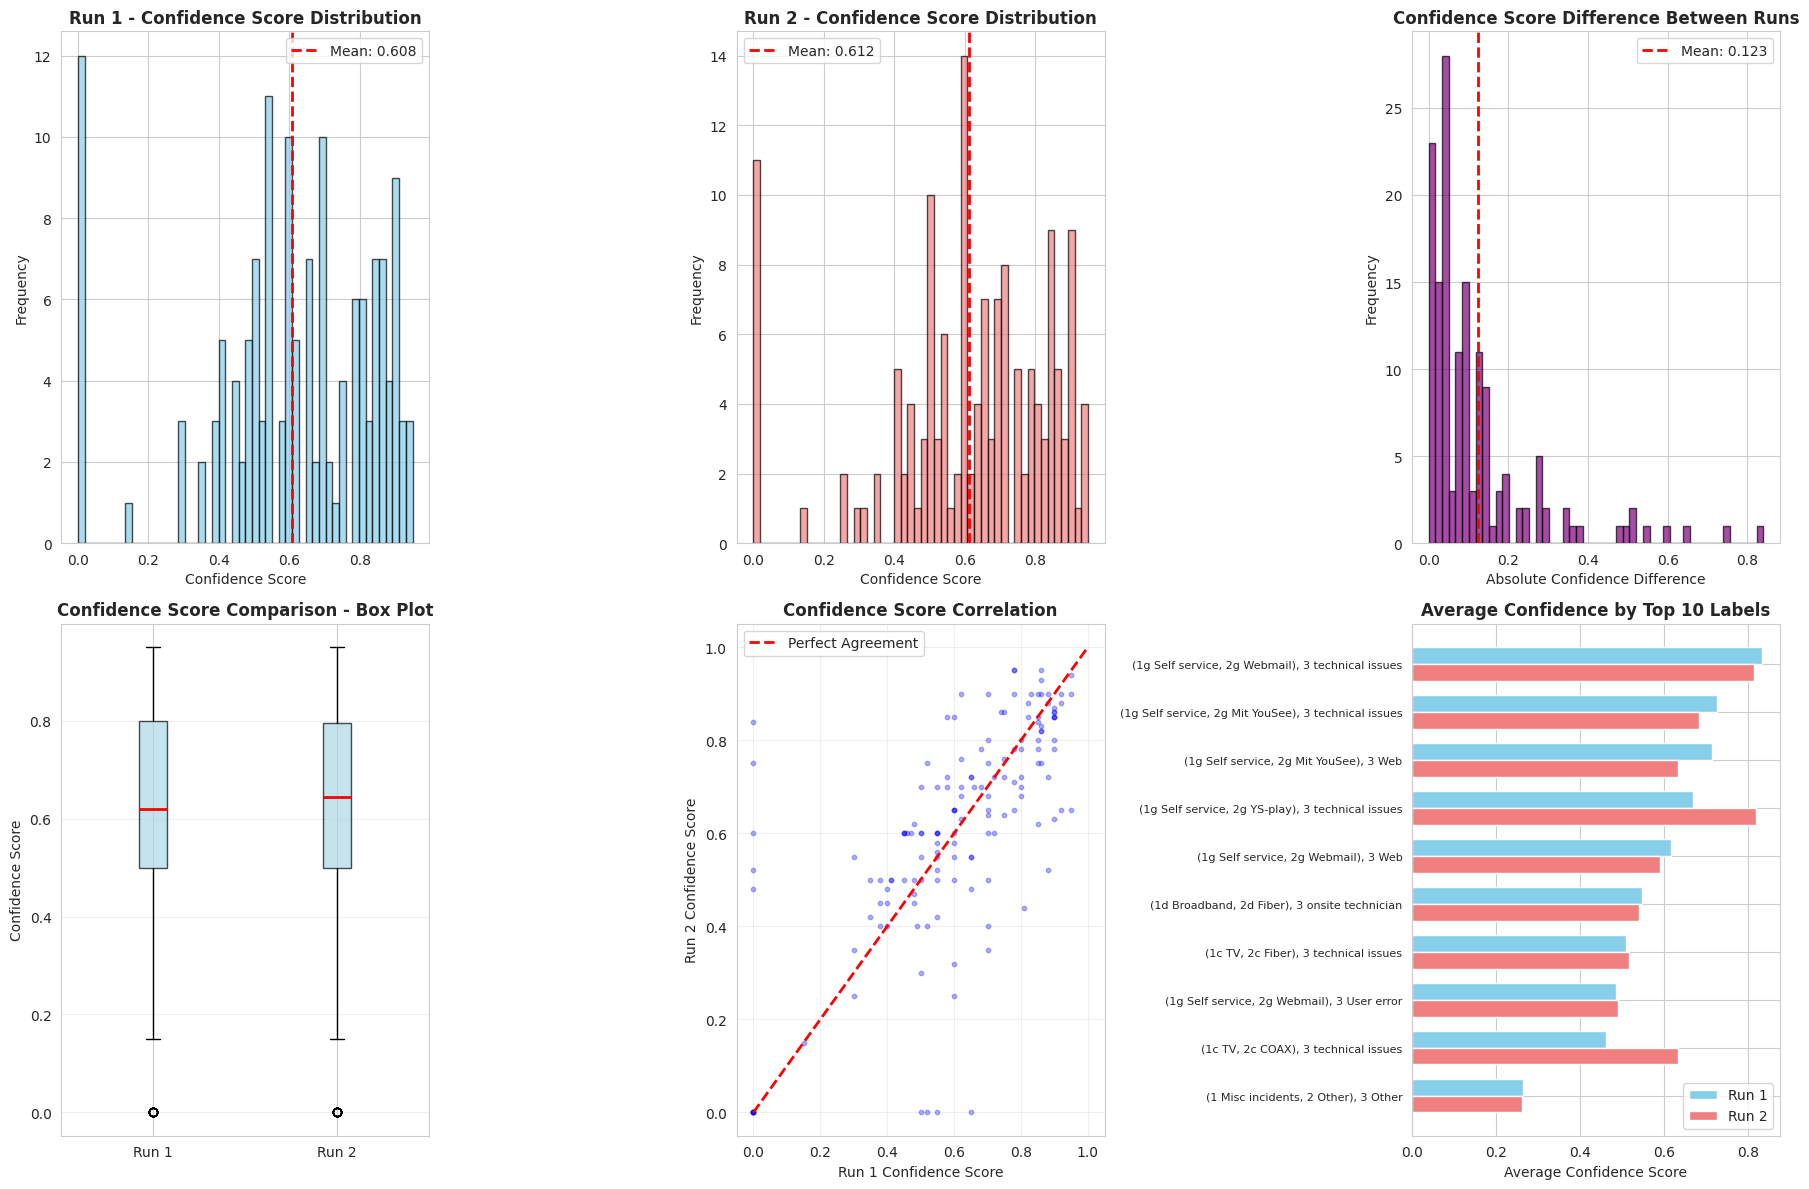


📊 Visualization saved to: ../data/confidence_analysis.png


In [14]:
# Confidence score analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Run 1 - Confidence distribution
axes[0, 0].hist(df1['confidence_score'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df1['confidence_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df1["confidence_score"].mean():.3f}')
axes[0, 0].set_xlabel('Confidence Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Run 1 - Confidence Score Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# Run 2 - Confidence distribution
axes[0, 1].hist(df2['confidence_score'], bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(df2['confidence_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df2["confidence_score"].mean():.3f}')
axes[0, 1].set_xlabel('Confidence Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Run 2 - Confidence Score Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# Confidence difference distribution
axes[0, 2].hist(conf_diff, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(conf_diff.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {conf_diff.mean():.3f}')
axes[0, 2].set_xlabel('Absolute Confidence Difference')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Confidence Score Difference Between Runs', fontsize=12, fontweight='bold')
axes[0, 2].legend()

# Box plot comparison
box_data = [df1['confidence_score'], df2['confidence_score']]
axes[1, 0].boxplot(box_data, labels=['Run 1', 'Run 2'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Confidence Score')
axes[1, 0].set_title('Confidence Score Comparison - Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Scatter plot: Run 1 vs Run 2 confidence
axes[1, 1].scatter(df1['confidence_score'], df2['confidence_score'], alpha=0.3, s=10, color='blue')
axes[1, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Agreement')
axes[1, 1].set_xlabel('Run 1 Confidence Score')
axes[1, 1].set_ylabel('Run 2 Confidence Score')
axes[1, 1].set_title('Confidence Score Correlation', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Confidence by label (top 10 labels)
top_labels = df1['label'].value_counts().head(10).index
df1_top = df1[df1['label'].isin(top_labels)]
df2_top = df2[df2['label'].isin(top_labels)]

label_conf_1 = df1_top.groupby('label')['confidence_score'].mean().sort_values(ascending=False)
label_conf_2 = df2_top.groupby('label')['confidence_score'].mean().reindex(label_conf_1.index)

x = np.arange(len(label_conf_1))
width = 0.35

axes[1, 2].barh(x - width/2, label_conf_1.values, width, label='Run 1', color='skyblue')
axes[1, 2].barh(x + width/2, label_conf_2.values, width, label='Run 2', color='lightcoral')
axes[1, 2].set_yticks(x)
axes[1, 2].set_yticklabels(label_conf_1.index, fontsize=8)
axes[1, 2].set_xlabel('Average Confidence Score')
axes[1, 2].set_title('Average Confidence by Top 10 Labels', fontsize=12, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()